In [43]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import shapiro, levene

import scikit_posthocs as sp

from scipy.stats import kruskal

from sklearn.decomposition import PCA

import numpy as np

from scipy.stats import spearmanr

import matplotlib.pyplot as plt

from matplotlib.patches import Wedge


from skbio import DistanceMatrix
from skbio.stats.distance import mantel

import pickle

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6359.96it/s]


In [26]:

# carico i dataset
synonym_df = pd.read_csv("synonym_pairs_final.csv")
antonym_df = pd.read_csv("antonym_pairs_final.csv")
random_df = pd.read_csv("random_pairs_final.csv")


#codice da eseguire per avere gli embedding modello contestuale

import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [31]:
#Estrazione delle PCA (50,10,2 D)
#converto dizionario di embedding in una matrice Numpy
#creo una lista contenente le chiavi del dizionario
words = list(embeddings.keys())
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix = np.vstack([
    embeddings[word].numpy()
    for word in words
])

print(embedding_matrix.shape)

(638, 384)


In [33]:
#PCA 50 D
pca_50 = PCA(n_components=50)
pca_50_embedding = pca_50.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 50 D:", pca_50_embedding.shape)
print("Varianza spiegata totale:", pca_50.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 50 D: (638, 50)
Varianza spiegata totale: 0.55795944


In [34]:
#PCA 10 D
pca_10 = PCA(n_components=10)
pca_10_embedding = pca_10.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 10 D:", pca_10_embedding.shape)
print("Varianza spiegata totale:", pca_10.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 10 D: (638, 10)
Varianza spiegata totale: 0.1961781


In [35]:
#PCA 2 D
pca_2 = PCA(n_components=2)
pca_2_embedding = pca_2.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 2 D:", pca_2_embedding.shape)
print("Varianza spiegata totale:", pca_2.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 2 D: (638, 2)
Varianza spiegata totale: 0.054590352


In [36]:
#riassunto:
print("Varianza spiegata totale di PCA 50 D:", pca_50.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 10 D:", pca_10.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 2 D:", pca_2.explained_variance_ratio_.sum())

Varianza spiegata totale di PCA 50 D: 0.55795944
Varianza spiegata totale di PCA 10 D: 0.1961781
Varianza spiegata totale di PCA 2 D: 0.054590352


In [37]:
#ricreo dizionari di embedding

diz_embeddings_pca_50 = {
    word: pca_50_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_10 = {
    word: pca_10_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_2 = {
    word: pca_2_embedding [i]
    for i, word in enumerate(words)
}

In [47]:
#rifaccio primo esperimento per le tre distribuzioni:


#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2, diz_embedding ):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata, il dizionario della PCA
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = diz_embedding[w1]
        emb2 = diz_embedding[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [48]:
#funzione per sinonimi

syn_df_50D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_50
)

syn_df_10D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_10
)

syn_df_2D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_2
)

print("Sinonimi PCA 50 D:\n" ,syn_df_50D.head() )
print("\n")
print("Sinonimi PCA 10 D:\n", syn_df_10D.head())
print("\n")
print("Sinonimi PCA 2 D:\n",syn_df_2D.head())

Sinonimi PCA 50 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.423961
1   ghastly      macabre  synonym          -0.005871
2     dodgy        dicey  synonym           0.333170
3  biweekly  fortnightly  synonym           0.273903
4   pouring      gushing  synonym           0.570936


Sinonimi PCA 10 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.475690
1   ghastly      macabre  synonym           0.195614
2     dodgy        dicey  synonym           0.110656
3  biweekly  fortnightly  synonym           0.656051
4   pouring      gushing  synonym           0.571535


Sinonimi PCA 2 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.350186
1   ghastly      macabre  synonym          -0.806425
2     dodgy        dicey  synonym           0.153129
3  biweekly  fortnightly  synonym           0.963233
4   pouring      gushing  synonym   

In [51]:
#funzione per contrari
ant_df_50D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_50
)

ant_df_10D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_10
)

ant_df_2D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_2
)

print("Contrari PCA 50 D:\n" ,ant_df_50D.head() )
print("\n")
print("Contrari PCA 10 D:\n", ant_df_10D.head())
print("\n")
print("Contrari PCA 2 D:\n",ant_df_2D.head())

Contrari PCA 50 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.875377
1  centralized  decentralized  antonym           0.709005
2   reasonable   unreasonable  antonym           0.709504
3       simple        complex  antonym           0.414643
4      legible      illegible  antonym           0.361101


Contrari PCA 10 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.879746
1  centralized  decentralized  antonym           0.740664
2   reasonable   unreasonable  antonym           0.823503
3       simple        complex  antonym           0.666234
4      legible      illegible  antonym           0.670357


Contrari PCA 2 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.996970
1  centralized  decentralized  antonym           0.656215
2   reasonable   unreasonable  antonym           0.892899
3       s

In [52]:
#Random
rand_df_50D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_50
)

rand_df_10D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_10
)

rand_df_2D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_2
)

print("Random PCA 50 D:\n" ,rand_df_50D.head())
print("\n")
print("Random PCA 10 D:\n" ,rand_df_10D.head())
print("\n")
print("Random PCA 2 D:\n" ,rand_df_2D.head())

Random PCA 50 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random          -0.008073
1  unpalatable  melancholic   random           0.162365
2     obliging     definite   random          -0.156356
3    punishing  recombinant   random          -0.020160
4      opposed        ionic   random           0.015166


Random PCA 10 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.092156
1  unpalatable  melancholic   random           0.259108
2     obliging     definite   random          -0.083556
3    punishing  recombinant   random           0.016797
4      opposed        ionic   random          -0.133607


Random PCA 2 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random          -0.788891
1  unpalatable  melancholic   random           0.277437
2     obliging     definite   random          -0.464236
3    punishing  recombinant   random           

In [63]:
#salvo i risultati
syn_df_50D.to_csv(
    "results_synonyms_similarity_PCA50.csv",
    index=False
)

syn_df_10D.to_csv(
    "results_synonyms_similarity_PCA10.csv",
    index=False
)

syn_df_2D.to_csv(
    "results_synonyms_similarity_PCA2.csv",
    index=False
)

ant_df_50D.to_csv(
    "results_antonyms_similarity_PCA50.csv",
    index=False
)

ant_df_10D.to_csv(
    "results_antonyms_similarity_PCA10.csv",
    index=False
)

ant_df_2D.to_csv(
    "results_antonyms_similarity_PCA2.csv",
    index=False
)

rand_df_50D.to_csv(
    "results_random_similarity_PCA50.csv",
    index=False
)

rand_df_10D.to_csv(
    "results_random_similarity_PCA10.csv",
    index=False
)

rand_df_2D.to_csv(
    "results_random_similarity_PCA2.csv",
    index=False
)

In [2]:
#per caricare dataset con cosine similarity

syn_df_50D = pd.read_csv("results_synonyms_similarity_PCA50.csv")
syn_df_10D = pd.read_csv("results_synonyms_similarity_PCA10.csv")
syn_df_2D = pd.read_csv("results_synonyms_similarity_PCA2.csv")
ant_df_50D = pd.read_csv("results_antonyms_similarity_PCA50.csv")
ant_df_10D = pd.read_csv("results_antonyms_similarity_PCA10.csv")
ant_df_2D = pd.read_csv("results_antonyms_similarity_PCA2.csv")
rand_df_50D = pd.read_csv("results_random_similarity_PCA50.csv")
rand_df_10D = pd.read_csv("results_random_similarity_PCA10.csv")
rand_df_2D = pd.read_csv("results_random_similarity_PCA2.csv")

In [55]:
#Statistiche descrittive
#sinonimi
print("SINONIMI")
print("Sinonimi per embedding a 50 dimensioni:\n")
print(syn_df_50D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 10 dimensioni:\n")
print(syn_df_10D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 2 dimensioni:\n")
print(syn_df_2D["cosine_similarity"].describe().round(3))
print("\nCONTRARI")
print("Contrari per embedding a 50 dimensioni:\n")
print(ant_df_50D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 10 dimensioni:\n")
print(ant_df_10D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 2 dimensioni:\n")
print(ant_df_2D["cosine_similarity"].describe().round(3))
print("\nRANDOM")
print("Random per embedding a 50 dimensioni:\n")
print(rand_df_50D["cosine_similarity"].describe().round(3))
print("Random per embedding a 10 dimensioni:\n")
print(rand_df_10D["cosine_similarity"].describe().round(3))
print("Random per embedding a 2 dimensioni:\n")
print(rand_df_2D["cosine_similarity"].describe().round(3))

SINONIMI
Sinonimi per embedding a 50 dimensioni:

count    111.000
mean       0.336
std        0.259
min       -0.168
25%        0.126
50%        0.361
75%        0.551
max        0.842
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 10 dimensioni:

count    111.000
mean       0.430
std        0.347
min       -0.430
25%        0.181
50%        0.511
75%        0.713
max        0.936
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 2 dimensioni:

count    111.000
mean       0.373
std        0.701
min       -1.000
25%       -0.191
50%        0.722
75%        0.970
max        1.000
Name: cosine_similarity, dtype: float64

CONTRARI
Contrari per embedding a 50 dimensioni:

count    111.000
mean       0.467
std        0.274
min       -0.158
25%        0.276
50%        0.525
75%        0.689
max        0.905
Name: cosine_similarity, dtype: float64
Contrari per embedding a 10 dimensioni:

count    111.000
mean       0.481
std        0.347
min       -0.469
25%  

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\3574747906.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


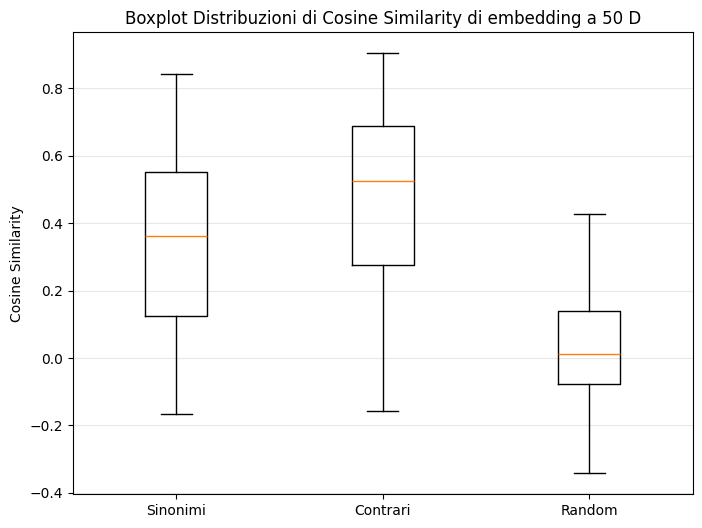

In [56]:
#BOX-Plot PCA 50 D:
#confronto tra le distribuzioni: box plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_50D["cosine_similarity"],
        ant_df_50D["cosine_similarity"],
        rand_df_50D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 50 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_50D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\3089064329.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


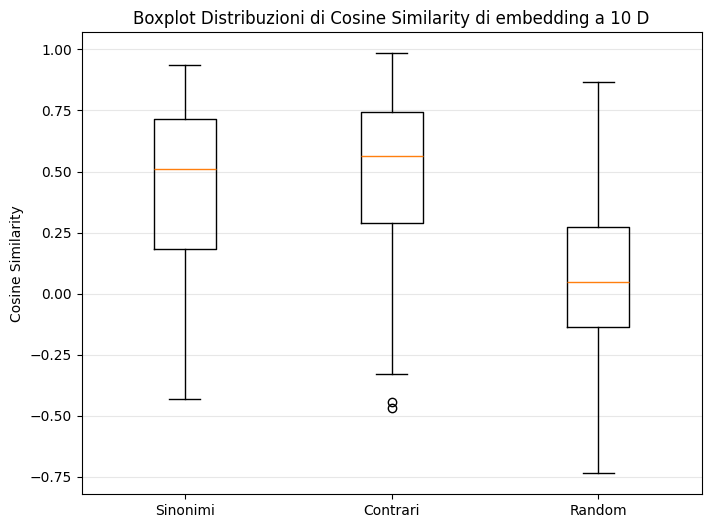

In [57]:
#BOX-Plot PCA 10 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_10D["cosine_similarity"],
        ant_df_10D["cosine_similarity"],
        rand_df_10D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 10 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_10D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\1874310280.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


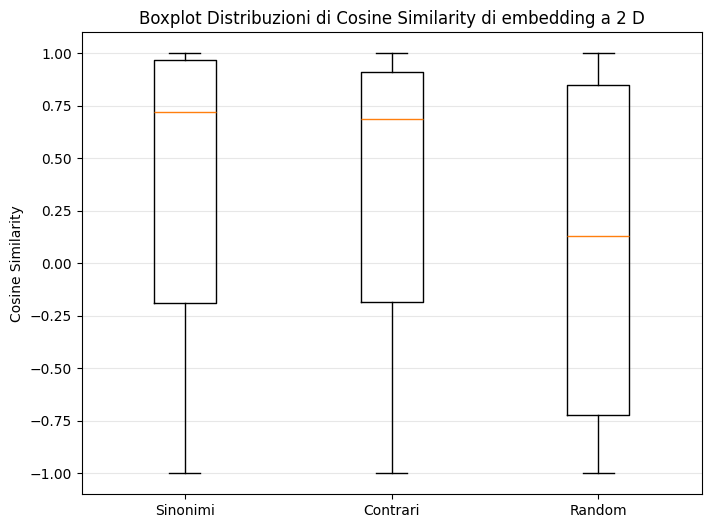

In [58]:
#BOX-Plot PCA 2 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_2D["cosine_similarity"],
        ant_df_2D["cosine_similarity"],
        rand_df_2D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 2 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_2D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [3]:
#Valutazione se usare Anova o meno 1:
#ci sono evidenze statistiche contro la normalità di distribuzione delle distanze?
#Shapiro-Wilk test


def Shapiro_test (syn_df, ant_df, rand_df):
    print("Shapiro-Wilk test\n")

    for nome, df in [
        ("Sinonimi", syn_df),
        ("Contrari", ant_df),
        ("Random", rand_df)
    ]:

        statistic, p_value = shapiro(df["cosine_similarity"])

        print(f"{nome}")
        print(f"W = {statistic:.4f}")
        print(f"p-value = {p_value:.4f}")

        if p_value > 0.05:
            print("→ La Distribuzione è compatibile con la distribuzione normale.\n")
        else:
            print("→la distribuzione non è compatibile con la distribuzione normale.\n")
            
    return statistic, p_value

#PCA

print("PCA 50\n")
Shapiro_50D = Shapiro_test(syn_df_50D, ant_df_50D, rand_df_50D)
print("\nPCA 10\n")
Shapiro_10D = Shapiro_test(syn_df_10D, ant_df_10D, rand_df_10D)
print("\nPCA 2\n")
Shapiro_2D = Shapiro_test(syn_df_2D, ant_df_2D, rand_df_2D)

PCA 50

Shapiro-Wilk test

Sinonimi
W = 0.9767
p-value = 0.0490
→la distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.9629
p-value = 0.0035
→la distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.9927
p-value = 0.8217
→ La Distribuzione è compatibile con la distribuzione normale.


PCA 10

Shapiro-Wilk test

Sinonimi
W = 0.9416
p-value = 0.0001
→la distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.9240
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.9884
p-value = 0.4570
→ La Distribuzione è compatibile con la distribuzione normale.


PCA 2

Shapiro-Wilk test

Sinonimi
W = 0.8077
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.8187
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.8703
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione norm

In [4]:
#Test Lavene sull'omogeneità delle varianze tra le 3 distribuzioni (già dal boxplot potevamo ipotizzare che non lo fossero)
def Levene_test (syn_df, ant_df, rand_df):
    
    statistic, p_value = levene(
        syn_df["cosine_similarity"],
        ant_df["cosine_similarity"],
        rand_df["cosine_similarity"]
    )

    print("Levene test\n")

    print(f"Statistica = {statistic:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.05:
        print("→ Le varianze sono omogenee.")
    else:
        print("→ Le varianze NON sono omogenee.")
    return statistic, p_value

#PCA

Levene_50D = Levene_test(syn_df_50D, ant_df_50D, rand_df_50D)

Levene_10D = Levene_test(syn_df_10D, ant_df_10D, rand_df_10D)

Levene_2D = Levene_test(syn_df_2D, ant_df_2D, rand_df_2D)


Levene test

Statistica = 20.0277
p-value = 0.0000
→ Le varianze NON sono omogenee.
Levene test

Statistica = 0.2191
p-value = 0.8033
→ Le varianze sono omogenee.
Levene test

Statistica = 2.9328
p-value = 0.0546
→ Le varianze sono omogenee.


In [6]:
#si è scelto di usare un test non parametrico per definire se vi è una significativa differenza di distribuzione delle distanze:
#Test di Kruskall-Wallis
def kruskal_wallis_test(syn_df, ant_df, rand_df):
    
    risultati = stats.kruskal(syn_df["cosine_similarity"], ant_df["cosine_similarity"],  rand_df["cosine_similarity"])
    print(f"\n{risultati}")
    H = risultati.statistic.round(4)
    p_value = risultati.pvalue
    epsilon_quadrato = H / (len(syn_df["cosine_similarity"]) + len(ant_df["cosine_similarity"]) + len(rand_df["cosine_similarity"]) - 1)
    print(f"H = {H}")
    print(f"\np value = {p_value.round(4)}")
    print(f"\nEpsilon quadrato = {epsilon_quadrato.round(4)}")
    if p_value > 0.05:
        print("Non si riscontra alcuna differenza significativa nelle distribuzione delle distanze dei tre gruppi")
    else:
        print("\nAlmeno una distribuzione differisce significativamente dalle altre")
        
    return H, p_value, epsilon_quadrato

#PCA

Kruskal_50D = kruskal_wallis_test(syn_df_50D, ant_df_50D, rand_df_50D)

Kruskal_10D = kruskal_wallis_test(syn_df_10D, ant_df_10D, rand_df_10D)

Kruskal_2D = kruskal_wallis_test(syn_df_2D, ant_df_2D, rand_df_2D)



KruskalResult(statistic=np.float64(130.73223798324943), pvalue=np.float64(4.091242465435557e-29))
H = 130.7322

p value = 0.0

Epsilon quadrato = 0.3938

Almeno una distribuzione differisce significativamente dalle altre

KruskalResult(statistic=np.float64(71.358460580665), pvalue=np.float64(3.19673890366234e-16))
H = 71.3585

p value = 0.0

Epsilon quadrato = 0.2149

Almeno una distribuzione differisce significativamente dalle altre

KruskalResult(statistic=np.float64(12.310294434262573), pvalue=np.float64(0.0021225284897604902))
H = 12.3103

p value = 0.0021

Epsilon quadrato = 0.0371

Almeno una distribuzione differisce significativamente dalle altre


In [9]:
#test di Dunn con correzione di Holm per stabilire nello specifico quali distribuzioni differiscono
#unisco i dataset
def Dunn_test(syn_df, ant_df, rand_df):
    df_all = pd.concat([
        syn_df.assign(group="Synonyms"),
        ant_df.assign(group="Antonyms"),
        rand_df.assign(group="Random")
    ])
    
    dunn = sp.posthoc_dunn(
        df_all,
        val_col="cosine_similarity",
        group_col="group",
        p_adjust="holm"
    )
    
    print(f"{dunn.round(4)}\n")
    return dunn

#PCA

Dunn_50D = Dunn_test(syn_df_50D, ant_df_50D, rand_df_50D)

Dunn_10D = Dunn_test(syn_df_10D, ant_df_10D, rand_df_10D)

Dunn_2D = Dunn_test(syn_df_2D, ant_df_2D, rand_df_2D)

          Antonyms  Random  Synonyms
Antonyms    1.0000     0.0    0.0029
Random      0.0000     1.0    0.0000
Synonyms    0.0029     0.0    1.0000

          Antonyms  Random  Synonyms
Antonyms     1.000     0.0     0.274
Random       0.000     1.0     0.000
Synonyms     0.274     0.0     1.000

          Antonyms  Random  Synonyms
Antonyms    1.0000  0.0289    0.3395
Random      0.0289  1.0000    0.0020
Synonyms    0.3395  0.0020    1.0000



In [10]:
#calcolo il delta per ogni coppia
from cliffs_delta import cliffs_delta

def Cliff_delta (syn_df, ant_df, rand_df):
    D_antvssyn = cliffs_delta( ant_df["cosine_similarity"], syn_df["cosine_similarity"])
    D, res = D_antvssyn
    print(f"\nContrari vs Sinonimi:{D,res}")

    D_antvsrand = cliffs_delta( ant_df["cosine_similarity"], rand_df["cosine_similarity"])
    D, res = D_antvsrand
    print(f"Contrari vs Random:{D,res}")

    D_synvsrand = cliffs_delta( syn_df["cosine_similarity"], rand_df["cosine_similarity"])
    D, res = D_synvsrand
    print(f"Sinonimi vs Random:{D,res}\n")
    
    return D_antvssyn, D_antvsrand, D_synvsrand


#PCA

Cliff_50D = Cliff_delta (syn_df_50D, ant_df_50D, rand_df_50D)

Cliff_10D = Cliff_delta (syn_df_10D, ant_df_10D, rand_df_10D)

Cliff_2D = Cliff_delta (syn_df_2D, ant_df_2D, rand_df_2D)


Contrari vs Sinonimi:(0.2757081405730054, 'small')
Contrari vs Random:(0.8131645158672186, 'large')
Sinonimi vs Random:(0.6708059410762114, 'large')


Contrari vs Sinonimi:(0.09293076860644428, 'negligible')
Contrari vs Random:(0.5974352731109488, 'large')
Sinonimi vs Random:(0.5286096907718529, 'large')


Contrari vs Sinonimi:(-0.08692476260043827, 'negligible')
Contrari vs Random:(0.2026621215810405, 'small')
Sinonimi vs Random:(0.25119714308903496, 'small')



In [13]:
#carico i dataset con cosine similarity degli embedding originali

orig_syn_df = pd.read_csv("results_synonyms_similarity.csv")
orig_ant_df = pd.read_csv("results_antonyms_similarity.csv")
orig_rand_df = pd.read_csv("results_random_similarity.csv")

In [22]:
#verificare la correlazione tra cosine similarity originale e quelle ridotte
def spearman (df_originale, df_pca):
    res = stats.spearmanr(df_originale["cosine_similarity"], df_pca["cosine_similarity"])
    print(f"Risultati:\n")
    print(f" rho = {res.statistic}")
    print(f"\np value = {res.pvalue.round(4)}\n")
    return res

#Confronti sinonimi
print("Sinonimi")
print("\noriginale vs 50\n")
syn_origvs50 = spearman (orig_syn_df, syn_df_50D)
print("\noriginale vs 10\n")
syn_origvs10 = spearman (orig_syn_df, syn_df_10D)
print("\noriginale vs 2\n")
syn_origvs2 = spearman (orig_syn_df, syn_df_2D)

Sinonimi

originale vs 50

Risultati:

 rho = 0.9419971919971919

p value = 0.0


originale vs 10

Risultati:

 rho = 0.8204282204282203

p value = 0.0


originale vs 2

Risultati:

 rho = 0.542128817128817

p value = 0.0



In [23]:
#Confronti Contrari
print("Contrari")
print("\noriginale vs 50\n")
ant_origvs50 = spearman (orig_ant_df, ant_df_50D)
print("\noriginale vs 10\n")
ant_origvs10 = spearman (orig_ant_df, ant_df_10D)
print("\noriginale vs 2\n")
ant_origvs2 = spearman (orig_ant_df, ant_df_2D)

Contrari

originale vs 50

Risultati:

 rho = 0.9626886626886626

p value = 0.0


originale vs 10

Risultati:

 rho = 0.813136188136188

p value = 0.0


originale vs 2

Risultati:

 rho = 0.39720954720954715

p value = 0.0



In [24]:
#Confronti Random
print("Random")
print("\noriginale vs 50\n")
rand_origvs50 = spearman (orig_rand_df, rand_df_50D)
print("\noriginale vs 10\n")
rand_origvs10 = spearman (orig_rand_df, rand_df_10D)
print("\noriginale vs 2\n")
rand_origvs2 = spearman (orig_rand_df, rand_df_2D)

Random

originale vs 50

Risultati:

 rho = 0.6267023517023517

p value = 0.0


originale vs 10

Risultati:

 rho = 0.4685591435591435

p value = 0.0


originale vs 2

Risultati:

 rho = 0.38044928044928045

p value = 0.0



In [27]:
syn_words = set(synonym_df["word"]) | set(synonym_df["synonym"])
ant_words = set(antonym_df["word"]) | set(antonym_df["antonym"])
rand_words = set(random_df["word"]) | set(random_df["random"])

all_words_categories = {}

for word in syn_words | ant_words | rand_words:
    categories = []

    if word in syn_words:
        categories.append("sinonimi")
    if word in ant_words:
        categories.append("contrari")
    if word in rand_words:
        categories.append("random")

    all_words_categories[word] = categories

In [28]:
for categories in [
    ("sinonimi",),
    ("contrari",),
    ("random",),
    ("sinonimi", "contrari"),
    ("sinonimi", "random"),
    ("contrari", "random"),
    ("sinonimi", "contrari", "random")
]:
    words = [
        word for word, cats in all_words_categories.items()
        if tuple(cats) == categories
    ]

    print(f"\n{categories}: {len(words)}")
    print(words)


('sinonimi',): 209
['damaging', 'striking', 'industrious', 'weird', 'pouring', 'beguiling', 'ferocious', 'aghast', 'annoying', 'angered', 'enthralling', 'groundless', 'yelled', 'rejoicing', 'scandalous', 'traitorous', 'eternal', 'desolate', 'detrimental', 'demolished', 'portrayed', 'toiling', 'bracing', 'unwavering', 'dauntless', 'soiled', 'noted', 'underweight', 'sceptical', 'provoking', 'faithless', 'strained', 'flustered', 'goofy', 'dreadful', 'subversive', 'puzzling', 'unforeseen', 'giddy', 'unclean', 'neglected', 'ingrained', 'bewildered', 'depicted', 'evoked', 'skilful', 'akin', 'revolved', 'masked', 'burdensome', 'superimposed', 'jubilant', 'exhausting', 'nauseating', 'strengthened', 'sterile', 'catastrophic', 'expert', 'merited', 'baseless', 'illustrious', 'dusky', 'impregnable', 'prolonged', 'clad', 'desirous', 'ruinous', 'fierce', 'agitating', 'loathsome', 'relocated', 'taxing', 'unanticipated', 'demonic', 'refreshing', 'staid', 'electrifying', 'disgraceful', 'disheartened',

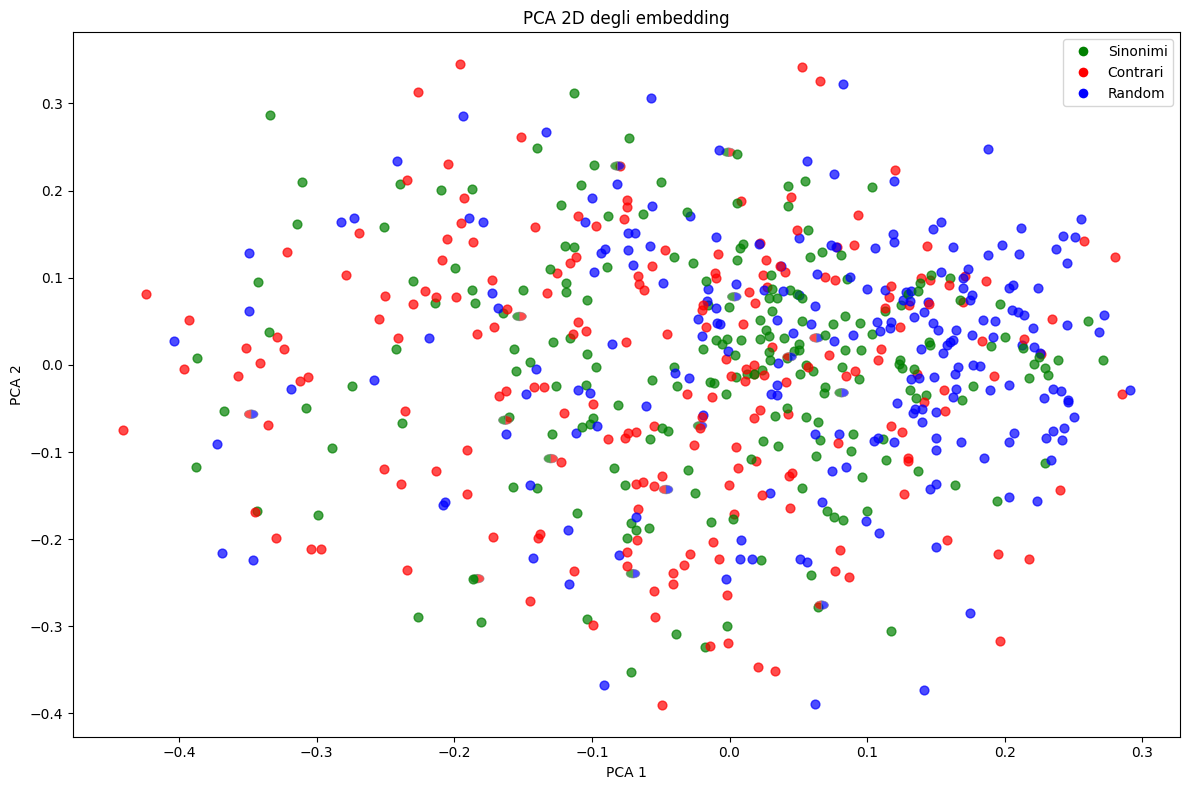

In [53]:

colors = {
    "sinonimi": "green",
    "contrari": "red",
    "random": "blue"
}

fig, ax = plt.subplots(figsize=(12, 8))

for i, word in enumerate(words):

    x = pca_2_embedding[i, 0]
    y = pca_2_embedding[i, 1]

    categories = all_words_categories[word]

    # Una sola categoria
    if len(categories) == 1:

        ax.scatter(
            x, y,
            color=colors[categories[0]],
            s=40,
            alpha=0.7
        )

    # Due categorie → pallino diviso a metà
    else:

        ax.add_patch(
            Wedge(
                (x, y),
                0.005,
                90,
                270,
                facecolor=colors[categories[0]],
                edgecolor="gray",
                linewidth=0.5,
                alpha=0.7
            )
        )

        ax.add_patch(
            Wedge(
                (x, y),
                0.005,
                270,
                90,
                facecolor=colors[categories[1]],
                edgecolor="gray",
                linewidth=0.5,
                alpha=0.7
            )
        )

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("PCA 2D degli embedding")

ax.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='green', markersize=8, label='Sinonimi'),
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='red', markersize=8, label='Contrari'),
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='blue', markersize=8, label='Random')
    ]
)

plt.tight_layout()

plt.savefig(
    "scatterplotPCA2D",
    dpi=300,
    bbox_inches="tight"
)

plt.show()